In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hdi_df=pd.read_csv('/content/drive/MyDrive/Concept and Technology of AI/Human_Development_Index_Dataset.csv',encoding='latin1')

3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)

In [4]:
# Task 1: Identify unique years and extract data for the year 2022

print("Years in the dataset:")
print(hdi_df["year"].unique())
hdi_2022_df = hdi_df[hdi_df["year"] == 2022].copy()


Years in the dataset:
[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


In [5]:
# Task 2: Display first 10 rows, number of rows, columns, and data types

print("First 10 rows of 2022 data:")
display(hdi_2022_df.head(10))

print("Total rows:", hdi_2022_df.shape[0])
print("Total columns:", hdi_2022_df.shape[1])

print("Column data types:")
display(hdi_2022_df.dtypes)


First 10 rows of 2022 data:


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


Total rows: 206
Total columns: 30
Column data types:


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


In [6]:
# Task 3: Check missing values, duplicate rows, and special characters

print("Null values in each column:")
print(hdi_2022_df.isnull().sum())

print("Duplicate rows:", hdi_2022_df.duplicated().sum())

print(
    "Special character values:",
    (hdi_2022_df.isin(["-", "NA", "N/A"])).sum().sum()
)


Null values in each column:
Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64

In [7]:
# Task 4: Calculate mean, median, standard deviation, highest and lowest HDI

print("Mean HDI:", hdi_2022_df["hdi"].mean())
print("Median HDI:", hdi_2022_df["hdi"].median())
print("Standard Deviation of HDI:", hdi_2022_df["hdi"].std())

max_country, max_hdi = hdi_2022_df.loc[
    hdi_2022_df["hdi"].idxmax(), ["country", "hdi"]
]
print(f"Highest HDI country: {max_country} ({max_hdi})")

min_country, min_hdi = hdi_2022_df.loc[
    hdi_2022_df["hdi"].idxmin(), ["country", "hdi"]
]
print(f"Lowest HDI country: {min_country} ({min_hdi})")


Mean HDI: 0.7228872549019609
Median HDI: 0.7395
Standard Deviation of HDI: 0.15302880386427825
Highest HDI country: Switzerland (0.967)
Lowest HDI country: Somalia (0.38)


In [8]:
# Task 5: Filter countries with HDI > 0.800 and sort by GNI per capita

high_hdi_df = hdi_2022_df[hdi_2022_df["hdi"] > 0.800]

sorted_by_gni = high_hdi_df.sort_values(
    by="gross_inc_percap",
    ascending=False
)

print("Top 10 countries with HDI > 0.800 sorted by GNI per capita:")
display(sorted_by_gni[["country", "gross_inc_percap"]].head(10))


Top 10 countries with HDI > 0.800 sorted by GNI per capita:


,country,gross_inc_percap
3332,Liechtenstein,146673.24150
4718,Qatar,95944.37754
5213,Singapore,88761.14559
2705,Ireland,87467.51391
3398,Luxembourg,78554.23640
6104,United Arab Emirates,74103.71494
5609,Switzerland,69432.78669
4322,Norway,69189.76165
6170,United States,65564.93798
2474,"Hong Kong, China (SAR)",62485.50516


In [10]:
# Task 6: Create HDI category column and save dataset

hdi_2022_df["HDI_Category"] = ""

for index, row in hdi_2022_df.iterrows():
    value = row["hdi"]
    if value < 0.550:
        hdi_2022_df.at[index, "HDI_Category"] = "Low"
    elif value > 0.550 and value < 0.699:
        hdi_2022_df.at[index, "HDI_Category"] = "Medium"
    elif value > 0.699 and value < 0.799:
        hdi_2022_df.at[index, "HDI_Category"] = "High"
    else:
        hdi_2022_df.at[index, "HDI_Category"] = "Very High"

print("First 5 rows after adding HDI_Category:")
display(hdi_2022_df.head())

hdi_2022_df.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/Human_Development_Index_Dataset.csv",
    index=False
)

print("File saved: HDI_category_added.csv")


First 5 rows after adding HDI_Category:


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,HDI_Category
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809,Low
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367,High
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199,High
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN,Very High
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568,Medium


File saved: HDI_category_added.csv


In [11]:
# Task 6: Create HDI category column and save dataset

hdi_2022_df["HDI_Category"] = ""

for index, row in hdi_2022_df.iterrows():
    value = row["hdi"]
    if value < 0.550:
        hdi_2022_df.at[index, "HDI_Category"] = "Low"
    elif value > 0.550 and value < 0.699:
        hdi_2022_df.at[index, "HDI_Category"] = "Medium"
    elif value > 0.699 and value < 0.799:
        hdi_2022_df.at[index, "HDI_Category"] = "High"
    else:
        hdi_2022_df.at[index, "HDI_Category"] = "Very High"

print("First 5 rows after adding HDI_Category:")
display(hdi_2022_df.head())

hdi_2022_df.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/Human_Development_Index_Dataset.csv",
    index=False
)

print("File saved: HDI_category_added.csv")


First 5 rows after adding HDI_Category:


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,HDI_Category
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809,Low
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367,High
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199,High
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN,Very High
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568,Medium


File saved: HDI_category_added.csv


3.2 Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)

In [13]:
# Task 1: Filter the dataset for years 2020, 2021, and 2022

hdi_2020_22_df = hdi_df[hdi_df["year"].isin([2020, 2021, 2022])].copy()

print("Filtered dataset for years 2020–2022 created.")

hdi_2020_22_df.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/Human_Development_Index_Dataset.csv",
    index=False
)
print("File saved: HDI_problem_1B.csv")


Filtered dataset for years 2020–2022 created.
File saved: HDI_problem_1B.csv


In [17]:
# Task 2: Check missing values, duplicates, and special characters

print("Missing values per column:")
print(hdi_2020_22_df.isnull().sum())

print("Duplicate rows:", hdi_2020_22_df.duplicated().sum())

print("Special character values:",
    (hdi_2020_22_df.isin(["-", "NA", "N/A"])).sum().sum()
)




Missing values per column:
Unnamed: 0                     0
iso3                           0
country                        0
year                           0
hdi                            8
life_expectancy                0
pop_millions                   0
hdi_f                         41
hdi_m                         41
life_expec_f                   0
life_expec_m                   0
expec_yr_school                5
expec_yr_school_f              5
expec_yr_school_m              5
mean_yr_school                 8
mean_yr_school_f               8
mean_yr_school_m               8
gross_inc_percap               6
gross_inc_percap_f            39
gross_inc_percap_m            39
gender_development            41
gender_inequality             89
secondary_education_f_%       53
secondary_education_m_%       53
seats_in_parliament_f_%        6
seats_in_parliament_m_%        6
labour_participation_f_%      36
labour_participation_m_%      36
co2_emission_tons              6
mat_footprint_pe

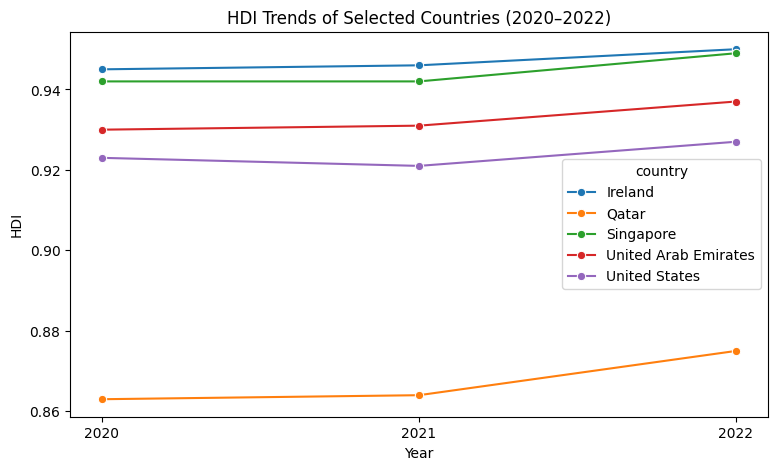

In [18]:
# Task 3A: Line chart showing HDI trends for selected countries

import matplotlib.pyplot as plt
import seaborn as sns

selected_countries = [ "Qatar", "Singapore", "Ireland","United States", "United Arab Emirates"]

line_df = hdi_2020_22_df[ hdi_2020_22_df["country"].isin(selected_countries)]

plt.figure(figsize=(9,5))
sns.lineplot(
    data=line_df,
    x="year",
    y="hdi",
    hue="country",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("HDI")
plt.title("HDI Trends of Selected Countries (2020–2022)")
plt.xticks([2020, 2021, 2022])
plt.show()


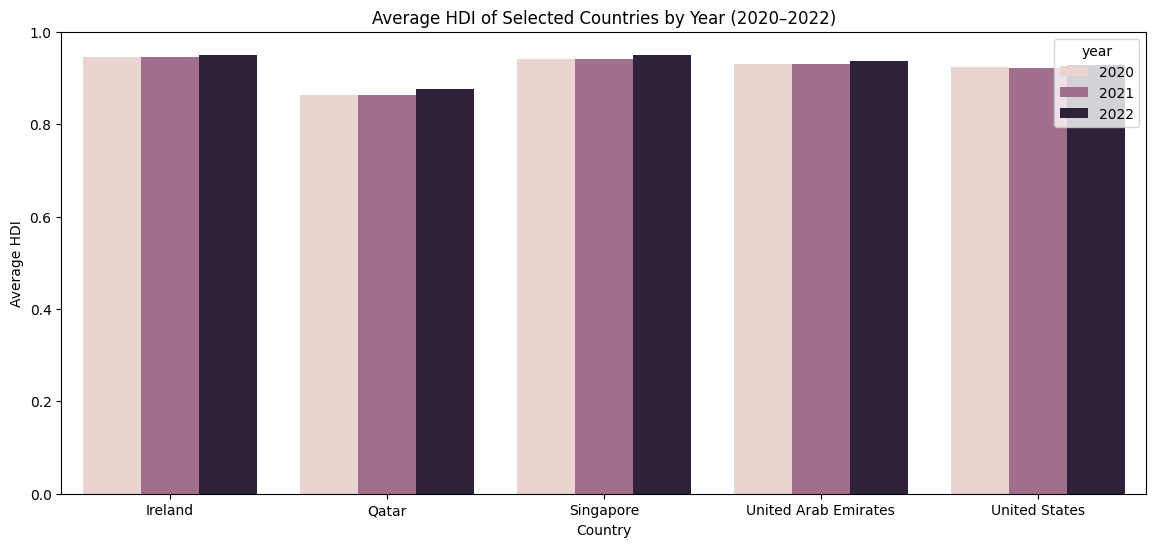

In [26]:
# Task 3B: Bar chart showing average HDI for selected countries by year

country_year_hdi = (
    line_df
    .groupby(["country", "year"], as_index=False)["hdi"]
    .mean()
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=country_year_hdi,
    x="country",
    y="hdi",
    hue="year"
)

plt.xlabel("Country")
plt.ylabel("Average HDI")
plt.title("Average HDI of Selected Countries by Year (2020–2022)")
plt.ylim(0,1)
plt.show()



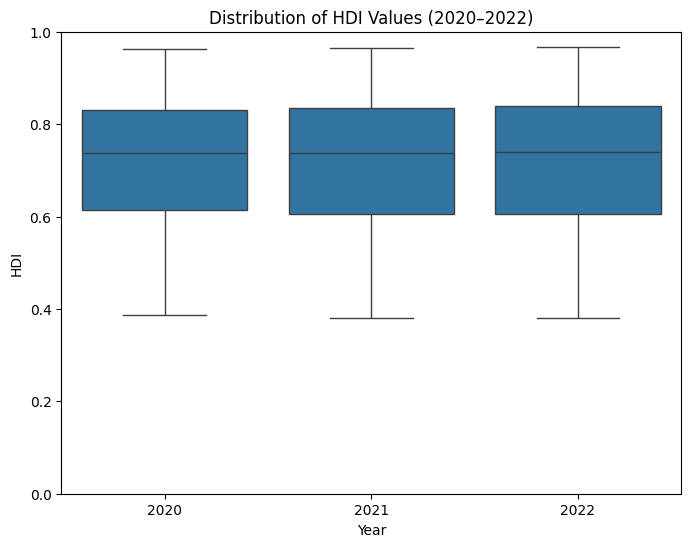

In [27]:
# Box plot showing distribution of HDI values (2020–2022)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=hdi_2020_22_df,
    x="year",
    y="hdi"
)

plt.xlabel("Year")
plt.ylabel("HDI")
plt.title("Distribution of HDI Values (2020–2022)")
plt.ylim(0,1)
plt.show()


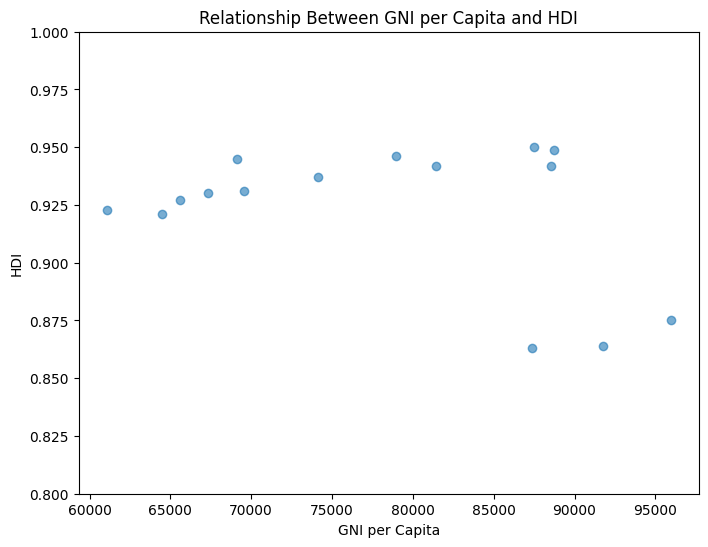

In [28]:
#Scatter plot showing relationship between GNI per capita and HDI

plt.figure(figsize=(8,6))
plt.scatter(
    line_df["gross_inc_percap"],
    line_df["hdi"],
    alpha=0.6
)

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Relationship Between GNI per Capita and HDI")
plt.ylim(0.8,1)
plt.show()


4 Problem 2
Advanced HDI Exploration

In [34]:
# Task 1: Filter South Asian countries

south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India","Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

south_asia_df = hdi_df[hdi_df["country"].isin(south_asia_countries)].copy()

south_asia_df.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/HDI_SouthAsia.csv",
    index=False
)

print("South Asia dataset Created.")


South Asia dataset Created.


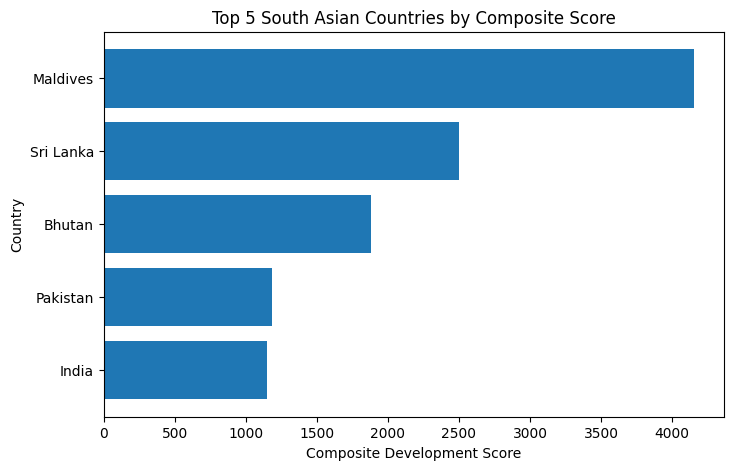

In [35]:
# Task 2: Composite Development Score

south_asia_df["Composite_Score"] = (
    0.30 * south_asia_df["life_expectancy"] +
    0.30 * south_asia_df["gross_inc_percap"]
)

country_composite = (
    south_asia_df
    .groupby("country", as_index=False)
    .agg({"Composite_Score": "mean", "hdi": "mean"})
)

composite_ranked = country_composite.sort_values(
    by="Composite_Score",
    ascending=False
)

top5 = composite_ranked.head(5)

plt.figure(figsize=(8,5))
plt.barh(top5["country"], top5["Composite_Score"])
plt.xlabel("Composite Development Score")
plt.ylabel("Country")
plt.title("Top 5 South Asian Countries by Composite Score")
plt.gca().invert_yaxis()
plt.show()


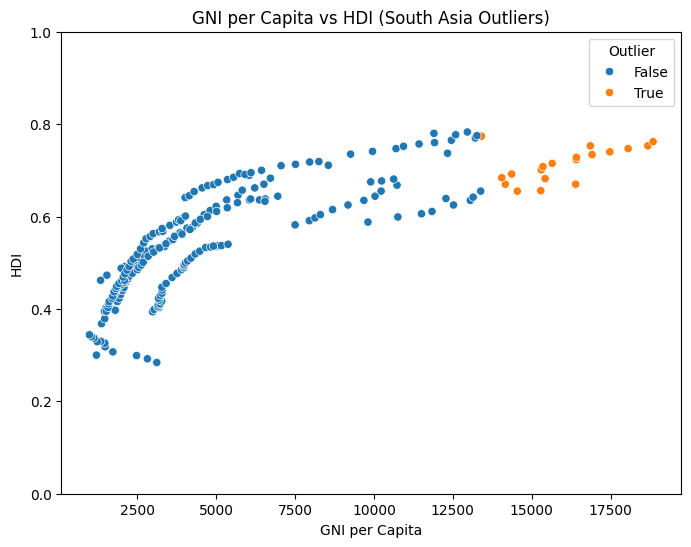

In [36]:
# Task 3: Outlier detection

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

south_asia_df["HDI_outlier"] = detect_outliers(south_asia_df["hdi"])
south_asia_df["GNI_outlier"] = detect_outliers(south_asia_df["gross_inc_percap"])
south_asia_df["Outlier"] = south_asia_df["HDI_outlier"] | south_asia_df["GNI_outlier"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=south_asia_df,
    x="gross_inc_percap",
    y="hdi",
    hue="Outlier"
)

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("GNI per Capita vs HDI (South Asia Outliers)")
plt.ylim(0,1)
plt.show()


gender_development vs HDI correlation: 0.866


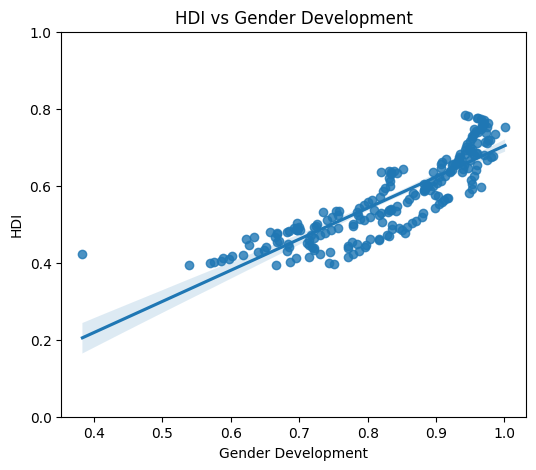

life_expectancy vs HDI correlation: 0.959


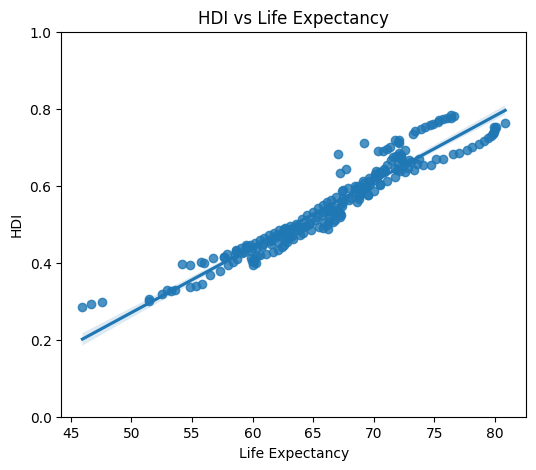

In [37]:
# Task 4: Correlation analysis

metrics = ["gender_development", "life_expectancy"]

for metric in metrics:
    corr = south_asia_df[metric].corr(south_asia_df["hdi"])
    print(f"{metric} vs HDI correlation: {corr:.3f}")

    plt.figure(figsize=(6,5))
    sns.regplot(
        data=south_asia_df,
        x=metric,
        y="hdi"
    )
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("HDI")
    plt.title(f"HDI vs {metric.replace('_',' ').title()}")
    plt.ylim(0,1)
    plt.show()


In [38]:
# Task 5: GNI–HDI Gap Analysis

south_asia_df["GNI_HDI_Gap"] = (
    south_asia_df["gross_inc_percap"] - south_asia_df["hdi"]
)

gap_summary = (
    south_asia_df
    .groupby("country", as_index=False)["GNI_HDI_Gap"]
    .mean()
)

top_positive = gap_summary.sort_values(
    by="GNI_HDI_Gap", ascending=False
).head(3)

top_negative = gap_summary.sort_values(
    by="GNI_HDI_Gap", ascending=True
).head(3)

print("Top 3 Countries with Highest GNI–HDI Gap")
print(top_positive)

print("\nTop 3 Countries with Lowest GNI–HDI Gap")
print(top_negative)


Top 3 Countries with Highest GNI–HDI Gap
     country   GNI_HDI_Gap
4   Maldives  14670.635594
2     Bhutan   9320.175767
7  Sri Lanka   8268.373527

Top 3 Countries with Lowest GNI–HDI Gap
       country  GNI_HDI_Gap
0  Afghanistan  1793.487770
5        Nepal  2532.443971
1   Bangladesh  3408.490410


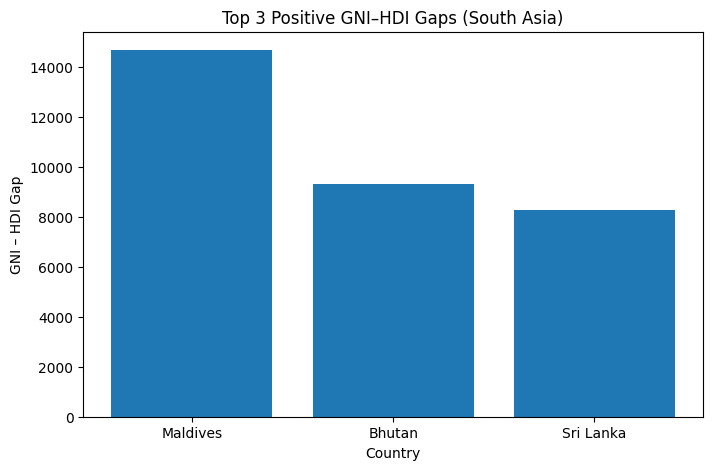

In [39]:
plt.figure(figsize=(8,5))
plt.bar(
    top_positive["country"],
    top_positive["GNI_HDI_Gap"]
)

plt.xlabel("Country")
plt.ylabel("GNI – HDI Gap")
plt.title("Top 3 Positive GNI–HDI Gaps (South Asia)")
plt.show()


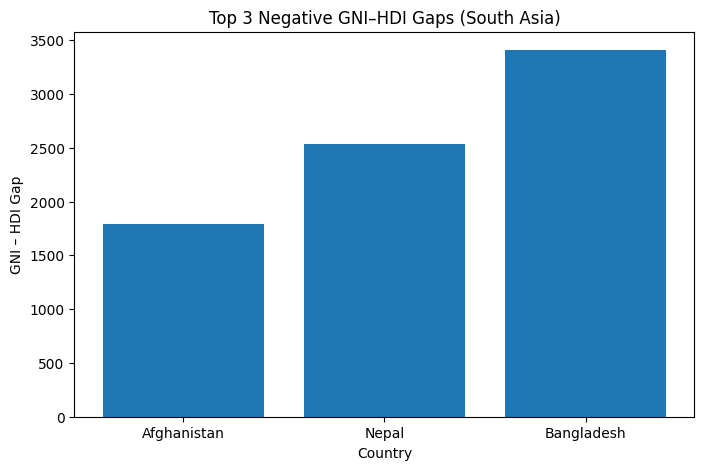

In [40]:
plt.figure(figsize=(8,5))
plt.bar(
    top_negative["country"],
    top_negative["GNI_HDI_Gap"]
)

plt.xlabel("Country")
plt.ylabel("GNI – HDI Gap")
plt.title("Top 3 Negative GNI–HDI Gaps (South Asia)")
plt.show()


In [42]:
# Task 1: Filter South Asia and Middle East data (2020–2022)

south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

south_asia_2020_22 = hdi_2020_22_df[
    hdi_2020_22_df["country"].isin(south_asia_countries)
].copy()

middle_east_2020_22 = hdi_2020_22_df[
    hdi_2020_22_df["country"].isin(middle_east_countries)
].copy()

south_asia_2020_22.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/HDI_SouthAsia_2020_2022.csv",
    index=False
)

middle_east_2020_22.to_csv(
    "/content/drive/MyDrive/Concept and Technology of AI/HDI_MiddleEast_2020_2022.csv",
    index=False
)

print("South Asia and Middle East datasets created.")


South Asia and Middle East datasets created.


In [43]:
# Task 2: Mean and Standard Deviation of HDI

def region_stats(df, region_name):
    mean_hdi = df["hdi"].mean()
    std_hdi = df["hdi"].std()
    print(f"{region_name}")
    print(f"Mean HDI : {mean_hdi:.3f}")
    print(f"Std Dev  : {std_hdi:.3f}\n")
    return mean_hdi

mean_sa = region_stats(south_asia_2020_22, "South Asia")
mean_me = region_stats(middle_east_2020_22, "Middle East")

better_region = "South Asia" if mean_sa > mean_me else "Middle East"
print("Region with higher average HDI:", better_region)


South Asia
Mean HDI : 0.640
Std Dev  : 0.098

Middle East
Mean HDI : 0.789
Std Dev  : 0.141

Region with higher average HDI: Middle East


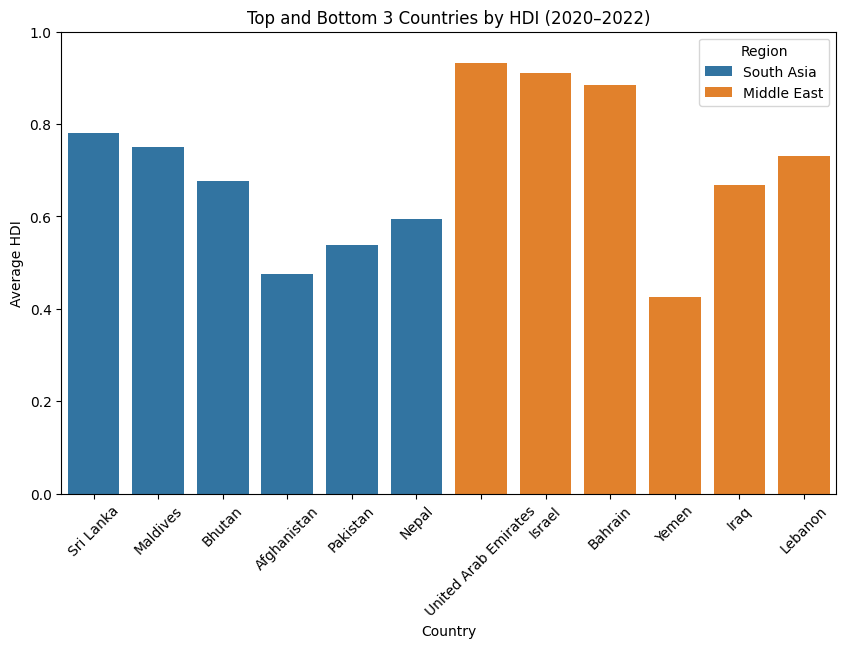

In [45]:
# Task 3: Top and Bottom 3 Countries by HDI (Bar Chart)

avg_sa = south_asia_2020_22.groupby("country", as_index=False)["hdi"].mean()
avg_me = middle_east_2020_22.groupby("country", as_index=False)["hdi"].mean()

top_bottom = pd.concat([
    avg_sa.sort_values("hdi", ascending=False).head(3).assign(Region="South Asia"),
    avg_sa.sort_values("hdi").head(3).assign(Region="South Asia"),
    avg_me.sort_values("hdi", ascending=False).head(3).assign(Region="Middle East"),
    avg_me.sort_values("hdi").head(3).assign(Region="Middle East")
])

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_bottom,
    x="country",
    y="hdi",
    hue="Region"
)

plt.xlabel("Country")
plt.ylabel("Average HDI")
plt.title("Top and Bottom 3 Countries by HDI (2020–2022)")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()



In [46]:
# Task 4: HDI variation (Range and Coefficient of Variation)

def hdi_variation(df, name):
    hdi_range = df["hdi"].max() - df["hdi"].min()
    cv = df["hdi"].std() / df["hdi"].mean()
    print(f"{name}")
    print(f"HDI Range : {hdi_range:.3f}")
    print(f"CV        : {cv:.3f}\n")
    return cv

cv_sa = hdi_variation(south_asia_2020_22, "South Asia")
cv_me = hdi_variation(middle_east_2020_22, "Middle East")

print(
    "Region with higher variation:",
    "South Asia" if cv_sa > cv_me else "Middle East"
)


South Asia
HDI Range : 0.321
CV        : 0.154

Middle East
HDI Range : 0.513
CV        : 0.179

Region with higher variation: Middle East


In [47]:
# Task 5: Correlation analysis

metrics = ["gender_development", "life_expectancy"]

for region, df in [
    ("South Asia", south_asia_2020_22),
    ("Middle East", middle_east_2020_22)
]:
    print(f"\n{region} Correlation Analysis")
    print("-" * 35)

    for metric in metrics:
        corr = df[metric].corr(df["hdi"])
        print(f"{metric.replace('_',' ').title()} vs HDI : {corr:.3f}")



South Asia Correlation Analysis
-----------------------------------
Gender Development vs HDI : 0.874
Life Expectancy vs HDI : 0.939

Middle East Correlation Analysis
-----------------------------------
Gender Development vs HDI : 0.936
Life Expectancy vs HDI : 0.933



South Asia correlations:
gender_development vs HDI: 0.874


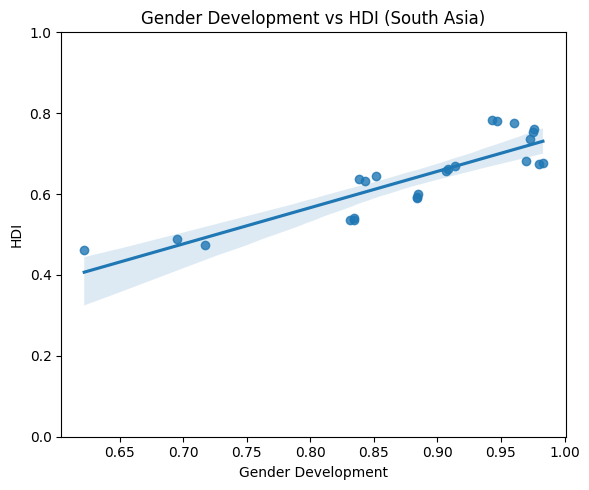

life_expectancy vs HDI: 0.939


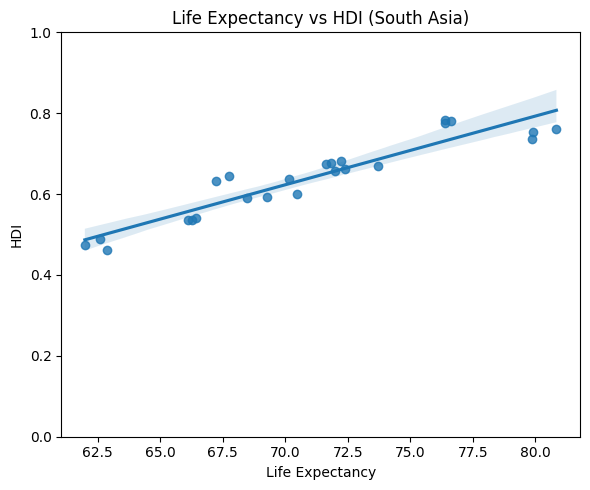


Middle East correlations:
gender_development vs HDI: 0.936


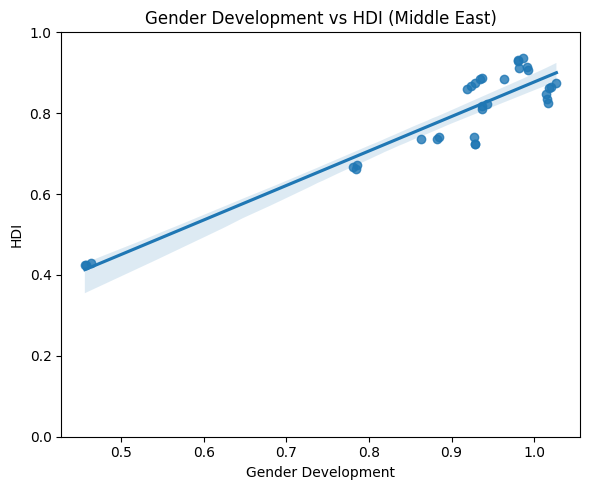

life_expectancy vs HDI: 0.933


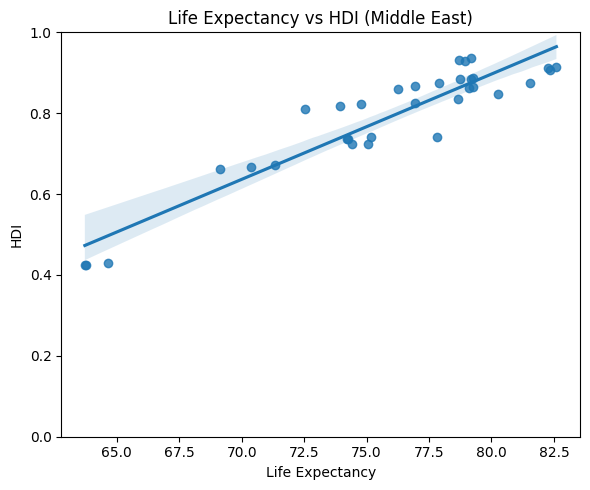

In [53]:
# Task 6: Correlation plots between HDI and development indicators

metrics_corr = ["gender_development", "life_expectancy"]

for region_name, df in [
    ("South Asia", south_asia_2020_22),
    ("Middle East", middle_east_2020_22)
]:
    print(f"\n{region_name} correlations:")

    for metric in metrics_corr:
        corr = df[metric].corr(df["hdi"])
        print(f"{metric} vs HDI: {corr:.3f}")

        plt.figure(figsize=(6,5))
        sns.regplot(
            data=df,
            x=metric,
            y="hdi"
        )
        plt.title(f"{metric.replace('_',' ').title()} vs HDI ({region_name})")
        plt.xlabel(metric.replace("_"," ").title())
        plt.ylabel("HDI")
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()
        plt.close()





Outliers in South Asia
Empty DataFrame
Columns: [country, year, hdi, gross_inc_percap]
Index: []


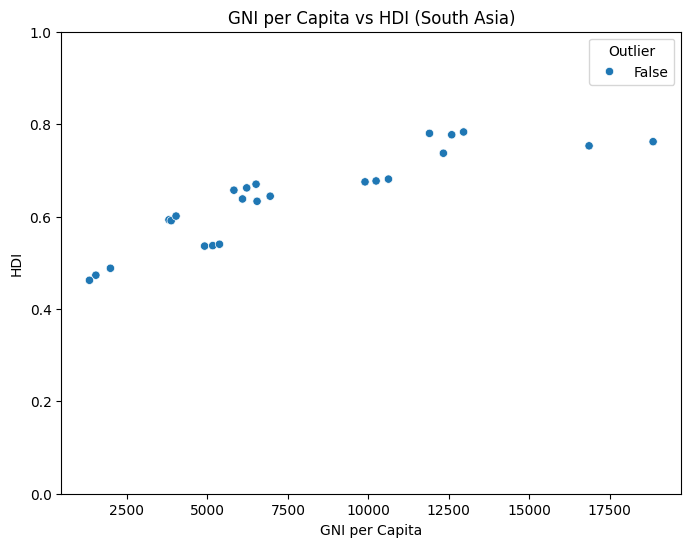


Outliers in Middle East
     country  year    hdi  gross_inc_percap
6366   Yemen  2020  0.430       1152.015672
6367   Yemen  2021  0.425       1112.162989
6368   Yemen  2022  0.424       1105.763435


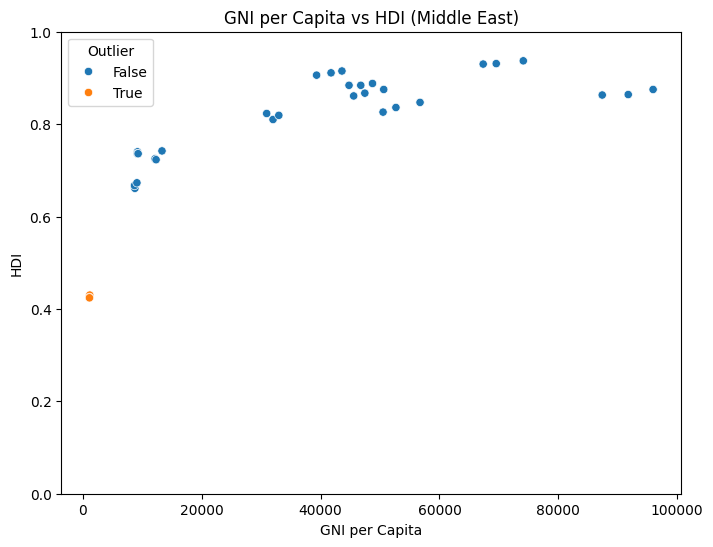

In [49]:
# Task 7: Outlier detection

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

for region, df in [
    ("South Asia", south_asia_2020_22),
    ("Middle East", middle_east_2020_22)
]:
    temp_df = df.copy()
    temp_df["Outlier"] = (
        detect_outliers(temp_df["hdi"]) |
        detect_outliers(temp_df["gross_inc_percap"])
    )

    print(f"\nOutliers in {region}")
    print(
        temp_df[temp_df["Outlier"]][
            ["country", "year", "hdi", "gross_inc_percap"]
        ]
    )

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=temp_df,
        x="gross_inc_percap",
        y="hdi",
        hue="Outlier"
    )
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.title(f"GNI per Capita vs HDI ({region})")
    plt.ylim(0,1)
    plt.show()
